In [1]:
%load_ext autoreload
%autoreload 2

# Identify whether a CUDA-enabled GPU is available
import torch
import pickle
import os
import sys
import pandas as pd
import numpy

# Optionally update sys.path for this notebook to import project code from parent directory.
sys.path.append("../..")

device = "cuda"

# data_home = "../../artefacts/data"
data_home = "../../../eeg_challenge/artefacts/data"

with open(os.path.join(data_home, "train_dataset_5sec.pkl"), "rb") as f:
    train_dataset = pickle.load(f)

with open(os.path.join(data_home, "valid_dataset.pkl"), "rb") as f:
    valid_dataset = pickle.load(f)

meta_information = train_dataset.get_metadata()
SFREQ = 100

In [2]:
meta_information_valid = valid_dataset.get_metadata()
default_rmse_valid = meta_information_valid['target'].std()
default_rmse_train = meta_information['target'].std()

print(f"Default std on train: {default_rmse_train:.4f}, on valid: {default_rmse_valid:.4f}")

Default std on train: 0.4088, on valid: 0.4054


In [3]:
from neurosned.foundation.parser import SFPParser

sfp_path = "GSN-HydroCel-129.sfp"
parser = SFPParser(sfp_path)
region_mapping = parser.channel_id_to_region()
print(f"Original region distribution: \n{pd.Series(region_mapping).value_counts()}")


Original region distribution: 
C     24
F     24
O     24
P     23
TL    17
TR    17
Name: count, dtype: int64


In [4]:
from neurosned.foundation.pseudo_devices import PseudoDevice
from neurosned.foundation.channels_splitter import DeviceSplitter

# Example usage
uniform_receipt = {"C": 8, 'F': 8, "O":8, "P": 7, "TL": 5, 'TR': 5}
splitter = DeviceSplitter(region_mapping, random_seed=42)
careful_pseudo_devices = splitter.uniform_split(uniform_receipt, n_devices=3, repeat=False)
random_pseudo_devices = splitter.random_split(n_devices=3, n_channels_per_device=41)
worst_pseudo_devices = splitter.worst_split(n_devices=3, n_channels_per_device=41)

# Test distributions of channels by region for each pseudodevice (uniform_split)
for name, devices in [
    ("uniform_split", careful_pseudo_devices),
    ("random_split", random_pseudo_devices),
    ("worst_split", worst_pseudo_devices)
]:
    for i, device in enumerate(devices):
        print(f"Pseudodevice ({name}) {i}:\n{device}\n")

Pseudodevice (uniform_split) 0:
<PseudoDevice(n_channels=41, reference_channel=118)>
  C: 8 -> 28, 31, 110, 111, 116, 117, 118, 128
  F: 8 -> 2, 7, 9, 11, 13, 15, 23, 24
  O: 8 -> 58, 67, 72, 73, 81, 87, 88, 89
  P: 7 -> 52, 57, 77, 84, 86, 91, 95
  TL: 5 -> 34, 37, 43, 44, 49
  TR: 5 -> 99, 101, 112, 115, 120

Pseudodevice (uniform_split) 1:
<PseudoDevice(n_channels=41, reference_channel=103)>
  C: 8 -> 0, 12, 26, 27, 35, 47, 103, 122
  F: 8 -> 1, 8, 10, 16, 18, 21, 123, 126
  O: 8 -> 64, 68, 70, 74, 76, 83, 90, 93
  P: 7 -> 30, 36, 53, 54, 59, 62, 78
  TL: 5 -> 32, 40, 46, 48, 55
  TR: 5 -> 96, 100, 102, 109, 121

Pseudodevice (uniform_split) 2:
<PseudoDevice(n_channels=41, reference_channel=124)>
  C: 8 -> 5, 6, 19, 29, 104, 105, 124, 127
  F: 8 -> 3, 4, 14, 17, 20, 22, 25, 125
  O: 8 -> 61, 65, 66, 69, 71, 75, 80, 82
  P: 7 -> 41, 51, 60, 79, 85, 94, 98
  TL: 5 -> 38, 39, 42, 50, 56
  TR: 5 -> 97, 106, 107, 113, 119

Pseudodevice (random_split) 0:
<PseudoDevice(n_channels=41, refer

In [ ]:
current_device = careful_pseudo_devices[0]

eeg_sample = train_dataset[0][0]
print(f"Original size: {eeg_sample.shape}")
transformed_sample = current_device.transform(eeg_sample)
print(f"Transformed sample shape (channel-last): {transformed_sample.shape}")

current_device_dataset = current_device.convert(train_dataset, drop_ref=True)
x_dev, *rest = current_device_dataset[0]
print(f"Shape after PseudoDeviceDataset conversion: {x_dev.shape}")

Original size: (129, 500)
Transformed sample shape (channel-last): (40, 500)
Shape after PseudoDeviceDataset conversion: torch.Size([40, 500])


In [6]:
#data hyperparameters
patch_size = 20
patch_overlap = 5
window_sec = 5
mask_ratio = 0.7
mask_block = 4
train_batch_size = 128
valid_batch_size = 128

# model
encoder_depth = 3
emb_dim = 16

# training
lr = 1e-4
weight_decay = 1e-6

# logging
output_dir = "../../artefacts/models/embeddings"
experiment_name = "reconstuction_only_good_device"


checkpoint_dir = os.path.join(output_dir, experiment_name)
os.makedirs(checkpoint_dir, exist_ok=True)

In [7]:
from torch.utils.data import ConcatDataset
from torch.utils.data import DataLoader

from neurosned.foundation.reconstruction_dataset import ReconstructionPatchDataset


train_dev_datasets = [dev.convert(train_dataset, drop_ref=True) for dev in careful_pseudo_devices]
valid_dev_datasets = [dev.convert(valid_dataset, drop_ref=True) for dev in careful_pseudo_devices]

train_merged = ConcatDataset(train_dev_datasets)
valid_merged = ConcatDataset(valid_dev_datasets)

train_recon_merged = ReconstructionPatchDataset(
    base=train_merged,
    sfreq=100,
    window_sec=window_sec,
    patch_size=patch_size,
    patch_overlap=patch_overlap,
    pad_to_window=False,
    return_full=True,
)
valid_recon_merged = ReconstructionPatchDataset(
    base=valid_merged,
    sfreq=100,
    window_sec=window_sec,
    patch_size=patch_size,
    patch_overlap=patch_overlap,
    pad_to_window=False,
    return_full=True,
)

train_loader = DataLoader(train_recon_merged, batch_size=train_batch_size, shuffle=True, num_workers=4, collate_fn=train_recon_merged.collate_fn)
val_loader = DataLoader(valid_recon_merged, batch_size=valid_batch_size, shuffle=False, num_workers=4, collate_fn=valid_recon_merged.collate_fn)


In [9]:
import torch
from tqdm import tqdm

from neurosned.models.reconstruction.minimalistic import MinimalistReconstructor, make_block_mask
from neurosned.models.reconstruction.losses import reconstruction_loss


# 3) Model / optim
example_patches, _, _ = next(iter(train_loader))
n_channels = example_patches.shape[2]
patch_size = example_patches.shape[3]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MinimalistReconstructor(n_channels=n_channels, patch_size=patch_size, embed_dim=emb_dim, depth=encoder_depth).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# 4) Training + validation loop (masked reconstruction)
import json

num_epochs = 5
metrics = {
    "epoch": [],
    "train_mse": [],
    "val_mse": [],
}
best_val_mse = float('inf')

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    n_batches = 0
    with tqdm(train_loader, desc=f"Epoch {epoch}", unit="batch") as tbar:
        for patches, starts, x_full in tbar:
            patches = patches.to(device)  # (B,P,C,T)
            B, P = patches.shape[:2]
            mask = make_block_mask(P, mask_ratio=mask_ratio, block_size=mask_block, device=patches.device)
            mask = mask.unsqueeze(0).expand(B, -1)  # (B,P)

            opt.zero_grad()
            out = model(patches, mask=mask)
            loss = reconstruction_loss(out["recon"], patches, mask=mask)
            loss.backward()
            opt.step()

            batch_loss = loss.item()
            running_loss += batch_loss
            n_batches += 1
            tbar.set_postfix(loss=f"{batch_loss:.4f}")

    train_mse = running_loss / max(1, n_batches)

    model.eval()
    val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        with tqdm(val_loader, desc=f"Val {epoch}", unit="batch") as vbar:
            for patches, starts, x_full in vbar:
                patches = patches.to(device)
                B, P = patches.shape[:2]
                mask = make_block_mask(P, mask_ratio=mask_ratio, block_size=mask_block, device=patches.device)
                mask = mask.unsqueeze(0).expand(B, -1)

                out = model(patches, mask=mask)
                loss = reconstruction_loss(out["recon"], patches, mask=mask)
                val_loss += loss.item()
                val_batches += 1
                vbar.set_postfix(val_loss=f"{loss.item():.4f}")
    val_mse = val_loss / max(1, val_batches)

    # Save metrics for this epoch
    metrics["epoch"].append(epoch)
    metrics["train_mse"].append(train_mse)
    metrics["val_mse"].append(val_mse)

    # Write metrics to file after each epoch
    metrics_path = os.path.join(checkpoint_dir, "metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)
    checkpoint_dict = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": opt.state_dict(),
            "val_mse": val_mse,
        }
    checkpoint_path = os.path.join(checkpoint_dir, "last.pt")
    torch.save(checkpoint_dict, checkpoint_path)
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        checkpoint_path = os.path.join(checkpoint_dir, "best.pt")
        torch.save(checkpoint_dict, checkpoint_path)
        print(f"Saved best checkpoint to {checkpoint_path} (val_mse={val_mse:.6f})")

    print(f"epoch {epoch}: train masked-MSE {train_mse:.6f} | val masked-MSE {val_mse:.6f}")


Val 1: 100%|██████████| 541/541 [00:13<00:00, 38.76batch/s, val_loss=0.1921]


Saved best checkpoint to ../../artefacts/models/embeddings/reconstuction_only_good_device/best.pt (val_mse=0.243932)
epoch 1: train masked-MSE 28.298435 | val masked-MSE 0.243932


Val 2: 100%|██████████| 541/541 [00:13<00:00, 38.85batch/s, val_loss=0.0496]


Saved best checkpoint to ../../artefacts/models/embeddings/reconstuction_only_good_device/best.pt (val_mse=0.063049)
epoch 2: train masked-MSE 1.028115 | val masked-MSE 0.063049


Val 3: 100%|██████████| 541/541 [00:13<00:00, 39.13batch/s, val_loss=0.0072]


Saved best checkpoint to ../../artefacts/models/embeddings/reconstuction_only_good_device/best.pt (val_mse=0.030977)
epoch 3: train masked-MSE 0.262334 | val masked-MSE 0.030977


Val 4: 100%|██████████| 541/541 [00:13<00:00, 38.96batch/s, val_loss=0.0033]


Saved best checkpoint to ../../artefacts/models/embeddings/reconstuction_only_good_device/best.pt (val_mse=0.024618)
epoch 4: train masked-MSE 0.090817 | val masked-MSE 0.024618


Val 5: 100%|██████████| 541/541 [00:13<00:00, 38.78batch/s, val_loss=0.0023]

Saved best checkpoint to ../../artefacts/models/embeddings/reconstuction_only_good_device/best.pt (val_mse=0.022100)
epoch 5: train masked-MSE 0.050431 | val masked-MSE 0.022100


In [10]:
elem = next(iter(train_merged))

In [ ]:
elem[1][0]

1.7479999999999976

The rest is temporary frozen - it should be useful to solve downstream task

### Convert regression target to segmentation

In [3]:
import torch

def soft_label_1d(
    y_sec: torch.Tensor,
    T: int,
    dt: float,
    sigma: float | torch.Tensor = 0.12,
    density: bool = True,
    eps: float = 1e-8,
) -> torch.Tensor:
    y_sec = y_sec.to(torch.float32).view(-1)                 # (B,)
    B = y_sec.numel()
    device = y_sec.device
    u_star = (y_sec / dt).clamp(0.0, T - 1e-6).unsqueeze(1)  # (B,1)
    grid = torch.arange(T, device=device, dtype=torch.float32).unsqueeze(0)  # (1,T)
    rel_sec = (grid - u_star) * dt                           # (B,T)
    if not torch.is_tensor(sigma):
        sigma = torch.tensor(float(sigma), device=device, dtype=torch.float32)
    sigma = sigma.to(torch.float32)
    sigma = sigma.view(-1, 1) if sigma.numel() > 1 else sigma.view(1, 1)
    if sigma.numel() == 1:
        sigma = sigma.expand(B, 1)                           # (B,1)
    q = torch.exp(-0.5 * (rel_sec / sigma).pow(2))           # (B,T)
    if density:
        q = q / (q.sum(dim=1, keepdim=True) + eps)
    else:
        q = q / q.amax(dim=1, keepdim=True).clamp_min(eps)
        idx = u_star.round().long().clamp_(0, T - 1).squeeze(1)
        q[torch.arange(B, device=device), idx] = 1.0
        q.clamp_(0, 1)
    return q

### `TrainCroppingDataset`

This dataset generates training samples for predicting **reaction time** from EEG.  

- Each item yields a cropped 2-second EEG segment (`X_crop`), a soft temporal label (`q`), and a scalar target (`y_rel_sec`). 
- The crop starts around **0.5 s after stimulus** with random jitter ±`cropping_offset`.  
- Optional augmentations include time-scaling, channel dropout, cutout, and Gaussian noise.  
- The soft label `q` is a 1-D Gaussian density centered at `y_rel_sec`, enabling smooth supervision.  
- Supports channel selection, crop probability, and end-time trimming.  
- Designed to train models robust to small temporal shifts in stimulus-locked EEG.


In [4]:
from torch.utils.data import Dataset
import random
import numpy as np
from torch.nn import functional as F

class TrainCroppingDataset(Dataset):
    """
    base[i] -> (X_full, y_abs), X_full: (C, T_full), y_abs: seconds from stimulus.
    Returns: X_crop (C,T_crop), q (T_crop,), y_rel_sec (scalar)
    """
    def __init__(
        self,
        base: Dataset,
        sfreq: float,
        crop_sec: float = 2.0,
        sigma: float = 0.12,
        cropping_offset: float = 0.2,
        crop_proba: float = 1.,
        dropout_range: float = 0.2,
        dropout_proba: float = 0.5,
        use_channels: list | None = None,
        end_time: float | None = None,
        use_augmentation: bool = False,
        
    ):
        self.base = base
        self.sfreq = float(sfreq)
        self.crop_sec = float(crop_sec)
        self.T_crop = int(round(self.crop_sec * self.sfreq))
        self.sigma = float(sigma)
        self.cropping_offset = cropping_offset
        self.crop_proba = crop_proba
        self.dropout_proba = dropout_proba
        self.dropout_range = dropout_range
        self.use_channels = use_channels
        self.end_time = end_time
        self.use_augmentation = use_augmentation
        self.dt = 1.0 / self.sfreq

    def __len__(self):
        return len(self.base)

    def _crop_segment(self, X_full, y_abs):
        """
        Crops a 2-second window that starts around the default 0.5 s offset
        with a random shift in [−cropping_offset, +cropping_offset] seconds.
        """
        if torch.rand((), device=X_full.device) < self.crop_proba:
            start_second = 0.5 + random.uniform(-self.cropping_offset, self.cropping_offset)  # e.g. −0.2…+0.2 s     
            start_second = max(start_second, y_abs - 2.)
            start_second = min(start_second, y_abs - self.cropping_offset) 
            start_second = np.clip(start_second, 0.5 - self.cropping_offset, 0.5 + self.cropping_offset)
            start_second = np.clip(start_second, 0, self.end_time - self.crop_sec)
        else:
            start_second = 0.5      
        start_point = int(round(start_second * self.sfreq))
        end_point = start_point + self.T_crop

        X_crop = X_full[:, start_point:end_point].contiguous().to(torch.float32)
        y_rel_sec = y_abs - start_second #target position in seconds from crop start
        return X_crop, y_rel_sec
    
    
    def _augment_segment(self, X: torch.Tensor, y_rel_sec: float):
        # X: (C,T), y_rel_sec: float in [0, crop_sec]
        C, T = X.shape

        # time scaling
        if torch.rand((), device=X.device) < 0.2:  # вероятность применить
            min_scale, max_scale = 0.8, 1.2        # ±20%
            eps = 1e-6

            lb = max(min_scale, (y_rel_sec / self.crop_sec) + eps)
            ub = max_scale
            scale = 1.0 if lb > ub else float(torch.empty((), device=X.device).uniform_(lb, ub))
            new_T = int(round(T * scale))

            X = F.interpolate(X.unsqueeze(0), size=new_T, mode='linear', align_corners=False).squeeze(0)

            if new_T > T:
                X = X[:, :T]
            elif new_T < T:
                X = F.pad(X, (0, T - new_T))
            y_rel_sec = y_rel_sec / scale

        # channel dropout
        if torch.rand((), device=X.device) < self.dropout_proba:
            # drop up to dropout_range% of channels
            drop = torch.rand((), device=X.device).item() * self.dropout_range
            if drop > 0:
                ch_mask = (torch.rand(C, device=X.device) > drop).to(X.dtype).unsqueeze(-1)  # (C,1)
                X = X * ch_mask

        # cutout
        if torch.rand((), device=X.device) < 0.25:
            seg_len = int(torch.randint(10, min(60, T) + 1, (1,), device=X.device))
            start = int(torch.randint(0, T - seg_len + 1, (1,), device=X.device))
            X[:, start:start + seg_len] = 0

        # gaussian noise
        if torch.rand((), device=X.device) < 0.2:
            noise_std = 0.03 * torch.randn((), device=X.device).abs().item() + 0.01
            X = X + torch.randn_like(X) * noise_std

        return X.contiguous(), y_rel_sec  # y_rel_sec не меняем (нет аугов по времени)

    def __getitem__(self, idx: int):
        batch = self.base[idx]              # expect (X_full, y_abs)
        X_full, y_abs = batch[0], batch[1]

        # to tensors
        X_full = torch.as_tensor(X_full)    # (C, T_full)
        y_abs = float(y_abs.item())

        # channel subset on (C,T)
        if self.use_channels is not None:
            X_full = X_full[self.use_channels, :]

        # optional truncate by end_time (sec)
        if self.end_time is not None:
            t_end = min(X_full.shape[1], int(round(self.end_time * self.sfreq)))
            X_full = X_full[:, :t_end]

        X_crop, y_rel_sec = self._crop_segment(X_full, y_abs)
        if self.use_augmentation:
            X_crop, y_rel_sec = self._augment_segment(X_crop, y_rel_sec)

        q = soft_label_1d(
            torch.tensor([y_rel_sec], dtype=torch.float32),
            T=self.T_crop, dt=self.dt, sigma=self.sigma, density=True
        ).squeeze(0)                         # (T_crop,)

        return X_crop, q, torch.tensor(y_rel_sec, dtype=torch.float32)

### `train_one_epoch` — single-epoch training loop for time-distribution targets

**Inputs.**  
`dataloader` yields `(X, q, y_rel)` where `X:(B,C,T)`, `q:(B,T)` is a soft time distribution, `y_rel:(B,)` is the target time (s).  
`model(X) → logits (B,1,T)`. Optimizer, device, and loss weights (`lambda_*`) control objectives.

**Losses (weighted).**  
- **CE** on soft labels `q` (optionally **focal**).  
- **Time RMSE** via expected time `t_hat = softmax(z/τ)·t_grid`.  
- Optional **KL**(q‖p), **Wasserstein-1** (CDF distance) and **entropy** regularization.  
- Optional **hazard** head: converts logits to discrete-time hazard, forms normalized event-time distribution with its own CE/RMSE/KL/WASS/entropy, scaled by `lambda_hazard`.

**Regularization.**  
Optional **mixup** over samples with bin-wise pairing by target time.

**Optimization.**  
Gradient accumulation (`grad_accum`), tqdm progress with per-batch metrics; returns `avg_loss`, dataset **NRMSE**, and a dict of averaged loss components.


In [5]:
from typing import Optional
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.nn import Module
from tqdm import tqdm

def train_one_epoch(
    dataloader: DataLoader,
    model: Module,
    optimizer,
    epoch: int,
    device,
    print_batch_stats: bool = True,
    temperature: float = 1.0,
    lambda_time: float = 1.0,
    lambda_ce: float = 1.0,
    lambda_kl: float = 0.0,
    lambda_wass: float = 0.0,
    lambda_entropy: float = 0.0, 
    lambda_focal: float = 0.0,   
    lambda_hazard: float = 0.0,
    mixup_p: float = 0.5,
    mixup_alpha: float = 0.4,
    grad_accum: int = 1,
):
    """Dataset must yield: X (B,C,T), q (B,T), y_rel (B,) seconds from crop start. model(X)->logits (B,1,T)."""
    model.train()

    total_loss = total_ce = total_rmse = total_kl = total_wass = 0.0
    sse, n_samples = 0.0, 0
    sum_y, sum_y2 = 0.0, 0.0

    n_batches = len(dataloader)
    progress = tqdm(enumerate(dataloader), total=n_batches, disable=not print_batch_stats)

    for i, (X, q, y_rel) in progress:
        X     = X.to(device).float()              # (B,C,T)
        q     = q.to(device).float()              # (B,T) soft distribution over T
        y_rel = y_rel.to(device).float().view(-1) # (B,)

        B, C, T = X.shape
        dt = 1.0 / float(model.sfreq)

        if mixup_p>0 and torch.rand((),device=X.device)<mixup_p:
            bins=50
            b=torch.clamp((y_rel/(T*dt)*bins).long(),0,bins-1)
            partner=torch.arange(B,device=X.device)
            valid=torch.zeros(B,dtype=torch.bool,device=X.device)
            for k in range(bins):
                g=torch.where(b==k)[0]
                if g.numel()>=2:
                    p=g[torch.randperm(g.numel(),device=X.device)]
                    partner[p]=p.roll(1)
                    valid[p]=True
            if valid.any():
                lam=torch.distributions.Beta(mixup_alpha,mixup_alpha).sample((B,)).to(X.device)
                lam=torch.where(valid,lam,torch.ones_like(lam))
                X=lam.view(-1,1,1)*X+(1-lam).view(-1,1,1)*X[partner]
                q=lam.view(-1,1)*q+(1-lam).view(-1,1)*q[partner]
                y_rel=lam*y_rel+(1-lam)*y_rel[partner]

        z = model(X).squeeze(1)                    # (B,T)

        log_p = F.log_softmax(z / temperature, dim=-1)
        p = torch.softmax(z / temperature, dim=-1)
        entropy = -(p * log_p).sum(dim=-1).mean()   # H(p)

        # focal-weighted CE
        if lambda_ce:
            if lambda_focal > 0:
                focal_weight = (1.0 - p.detach()).pow(lambda_focal)  # detach to avoid 2nd order grads
                ce = -((focal_weight * q) * log_p).sum(dim=-1).mean()
            else:
                ce = -(q * log_p).sum(dim=-1).mean()
        else:
            ce = torch.tensor(0.0, device=device)

        # RMSE (time), KL, WASS
        t_grid = (torch.arange(T, device=device, dtype=z.dtype) * dt)[None, :]
        t_hat = (torch.softmax(z / temperature, dim=-1) * t_grid).sum(dim=-1)
        # ce   = -(q * log_p).sum(dim=-1).mean() if lambda_ce else torch.tensor(0.0, device=device)
        rmse = F.mse_loss(t_hat, y_rel).sqrt()
        kl   = (q * (torch.log(q + 1e-8) - log_p)).sum(dim=-1).mean() if lambda_kl else torch.tensor(0.0, device=device)
        if lambda_wass>0:
            wass = (torch.abs(torch.cumsum(p, -1) - torch.cumsum(q, -1)).sum(-1).mean()) * dt
        else:
            wass = torch.tensor(0.0, device=device)

        base_loss = lambda_ce * ce + lambda_time * rmse + lambda_kl * kl + lambda_wass * wass + lambda_entropy * entropy

        haz_loss = torch.tensor(0.0, device=device)
        t_hat_haz = None
        if lambda_hazard > 0.0:
            x = z / temperature
            log_h   = F.logsigmoid(x)    # log σ(x_t)
            log1m_h = F.logsigmoid(-x)   # log (1-σ(x_t)) = log σ(-x_t)
            log_surv_prev = torch.cumsum(log1m_h, dim=-1) - log1m_h
            log_p_haz = log_h + log_surv_prev
            log_p_haz = log_p_haz - torch.logsumexp(log_p_haz, dim=-1, keepdim=True)
            p_haz = log_p_haz.exp()
            if lambda_ce:
                if lambda_focal > 0:
                    focal_w_h = (1.0 - p_haz.detach()).pow(lambda_focal)
                    ce_haz = -((focal_w_h * q) * log_p_haz).sum(dim=-1).mean()
                else:
                    ce_haz = -(q * log_p_haz).sum(dim=-1).mean()
            else:
                ce_haz = torch.tensor(0.0, device=device)

            t_hat_haz = (p_haz * t_grid).sum(dim=-1)
            rmse_haz  = F.mse_loss(t_hat_haz, y_rel).sqrt()
            kl_haz    = (q * (torch.log(q + 1e-8) - log_p_haz)).sum(dim=-1).mean() if lambda_kl else torch.tensor(0.0, device=device)
            wass_haz  = ((torch.abs(torch.cumsum(p_haz, -1) - torch.cumsum(q, -1)).sum(-1).mean()) * dt) if lambda_wass>0 else torch.tensor(0.0, device=device)
            entropy_haz = -(p_haz * log_p_haz).sum(dim=-1).mean()

            haz_loss = (lambda_ce * ce_haz + lambda_time * rmse_haz + lambda_kl * kl_haz + lambda_wass * wass_haz + lambda_entropy * entropy_haz)
        loss = base_loss + lambda_hazard * haz_loss

        # Gradient accumulation
        loss = loss / grad_accum
        loss.backward()
        if (i + 1) % grad_accum == 0 or (i + 1) == n_batches:
            optimizer.step()
            optimizer.zero_grad()

        total_loss += float(loss)
        total_ce   += float(ce)
        total_rmse += float(rmse)
        total_kl   += float(kl)
        total_wass += float(wass)

        diff = (t_hat.detach() - y_rel.detach())
        sse += torch.sum(diff * diff).item()
        n_samples += y_rel.numel()
        sum_y  += y_rel.detach().sum().item()
        sum_y2 += torch.sum(y_rel.detach() * y_rel.detach()).item()

        if print_batch_stats:
            rmse_ds = (sse / max(n_samples, 1)) ** 0.5
            mean_y = sum_y / max(n_samples, 1)
            var_y  = max((sum_y2 / max(n_samples, 1)) - mean_y**2, 1e-12)
            std_y  = var_y ** 0.5
            nrmse  = rmse_ds / std_y
            progress.set_description(
                f"Epoch {epoch} [{i+1}/{n_batches}] "
                f"Loss {loss:.4f} CE {ce:.4f} " 
                f"RMSE {rmse:.4f} KL {kl:.4f} WASS {wass:.4f} "
                f"NRMSE {nrmse:.4f} Entropy {entropy:.3f}"
            )
    rmse_ds  = (sse / max(n_samples, 1)) ** 0.5
    mean_y = sum_y / max(n_samples, 1)
    var_y  = max((sum_y2 / max(n_samples, 1)) - mean_y**2, 1e-12)
    std_y  = var_y ** 0.5
    nrmse  = rmse_ds / std_y

    avg_loss = total_loss / n_batches
    loss_dict = {
        "ce": total_ce / n_batches,
        "rmse": total_rmse / n_batches,
        "kl": total_kl / n_batches,
        "wass": total_wass / n_batches,
        "total": avg_loss,
    }
    print(f"NRMSE: {nrmse:.4f}", f"Total loss: {total_loss:.4f}", f"Total CE: {total_ce:.4f}", f"Total RMSE: {total_rmse:.4f}", f"Total KL: {total_kl:.4f}", f"Total WASS: {total_wass:.4f}")
    return avg_loss, nrmse, loss_dict

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def draw_batch(X, y, z, t_hat_abs, ce, rmse_time, T, dt, win_offset, q, temperature, n_samples=4, rows=2):
    """
    Visualizes batch outputs: predicted distribution, actual value, groundtruth soft label, and losses.

    Args:
        X: Input batch (B, C, T)
        y: Groundtruth absolute times (B,)
        z: logits.squeeze(1) (B, T)
        t_hat_abs: predicted absolute times (B,)
        ce: cross-entropy loss (float)
        rmse_time: regression loss (float)
        T: int, window size (time bins)
        dt: time step (float)
        win_offset: float, window offset
        y_rel: relative click (B,)
        q: soft labels (B, T)
        temperature: softmax temperature
        n_samples: number of samples to plot from batch
        rows: number of rows in grid plot
    """
    b = min(n_samples, X.shape[0])
    # Choose b random sample indices without replacement
    idxs = np.random.choice(X.shape[0], size=b, replace=False)
    cols = int(np.ceil(b / rows))
    plt.figure(figsize=(cols * 5, rows * 2))
    t_grid = (np.arange(T) * dt) + win_offset
    for plot_idx, i in enumerate(idxs):
        plt.subplot(rows, cols, plot_idx + 1)
        p = torch.softmax(z[i] / temperature, dim=-1).cpu().numpy()  # (T,)
        qi = q[i].cpu().numpy()
        plt.plot(t_grid, p, label="Predicted p(t)", color="blue")
        plt.plot(t_grid, qi, label="Soft label $q(t)$", color="green", linestyle="--", alpha=0.8)
        plt.axvline([t_hat_abs[i].cpu().item()], color="red", label="Predicted time", linestyle="--")
        plt.axvline([y[i].cpu().item()], color="black", label="Actual time", linestyle="--")
        plt.title(f"Sample {i} | CE: {ce:.3f} | RMSE: {rmse_time:.3f}")
        plt.xlabel("Time (sec)")
        plt.ylabel("Probability / Weight")
        plt.legend()
        plt.tight_layout()
    plt.show()

In [7]:
import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.nn import Module
from tqdm import tqdm

@torch.no_grad()
def valid_model(
    dataloader: DataLoader,
    model: Module,
    device,
    print_batch_stats: bool = True,
    channels_list: list = None,
    default_rmse: float = None,
    sigma: float = 0.10,
    temperature: float = 1.0,
    lambda_time: float = 1.0,
    win_offset: float = 0.5,
    use_soft_argmax: bool = True,
    plot_last_batch: bool = True,
):
    """model(X)->logits (B,1,T); y is click time (sec) from stimulus onset."""
    model.eval()

    n_batches = len(dataloader)
    it = tqdm(enumerate(dataloader), total=n_batches, disable=not print_batch_stats)

    total_loss = total_ce = total_rmse = 0.0
    sse_abs = 0.0
    n_samples = 0
    preds_abs, targets_abs = [], []

    for i, batch in it:
        X = batch[0].to(device).float()
        y = batch[1].to(device).float().view(-1)             # absolute times (B,)
        if channels_list is not None:
            X = X[:, channels_list, :]
        
        B, C, T = X.shape
        dt = 1.0 / float(model.sfreq)
        win_sec = T * dt

        # build soft labels in window coords
        y_rel = (y - win_offset).clamp(0.0, win_sec)
        q = soft_label_1d(y_rel, T=T, dt=dt, sigma=sigma, density=True)  # (B,T)

        logits = model(X)                 # (B,1,T)
        z = logits.squeeze(1)             # (B,T)

        # segmentation loss
        log_p = F.log_softmax(z / temperature, dim=-1)
        ce = -(q * log_p).sum(dim=-1).mean()

        # soft-argmax prediction (window coords) -> absolute
        if use_soft_argmax:
            t_grid = (torch.arange(T, device=device, dtype=z.dtype) * dt)[None, :]
            p = torch.softmax(z / temperature, dim=-1)
            t_hat_rel = (p * t_grid).sum(dim=-1)          # (B,)
            t_hat_abs = t_hat_rel + win_offset            # (B,)
        else:
            t_hat_abs = z.argmax(dim=-1) * dt + win_offset  # (B,)
  
        # regression loss in SAME frame as y (absolute)
        rmse_time = F.mse_loss(t_hat_abs, y).sqrt()
        loss = ce + lambda_time * rmse_time

        # accumulate
        total_loss += float(loss)
        total_ce += float(ce)
        total_rmse += float(rmse_time)

        diff_abs = (t_hat_abs - y).detach()
        sse_abs += torch.sum(diff_abs * diff_abs).item()
        n_samples += y.numel()

        preds_abs.extend(t_hat_abs.cpu().numpy())
        targets_abs.extend(y.cpu().numpy())

        if print_batch_stats:
            rmse = (sse_abs / max(n_samples, 1)) ** 0.5
            nrmse = rmse / default_rmse if default_rmse else rmse
            it.set_description(
                f"Val [{i+1}/{n_batches}] Loss {loss:.4f} CE {ce:.4f} RMSE {rmse_time:.4f} NRMSE {nrmse:.4f}"
            )
    avg_loss = total_loss / n_batches if n_batches else float("nan")
    avg_ce   = total_ce   / n_batches if n_batches else float("nan")
    avg_rmse  = total_rmse  / n_batches if n_batches else float("nan")
    rmse = (sse_abs / max(n_samples, 1)) ** 0.5 * 1000
    nrmse = rmse / default_rmse if default_rmse else rmse

    print(f"Val NRMSE: {nrmse:.3f}, Val Loss: {avg_loss:.6f}, Val CE: {avg_ce:.6f}, Val RMSE: {avg_rmse:.6f}")
    bias = (t_hat_abs - y).mean().item()
    print("mean bias (s):", bias)
    # Visualization: Draw last batch distributions for n_samples=4, 2 rows
    if plot_last_batch:
        draw_batch(
            X=X.cpu(),
            y=y.cpu(),
            z=z.cpu(),
            t_hat_abs=t_hat_abs.cpu(),
            ce=float(ce),
            rmse_time= float(rmse_time),
            T= T,
            dt= dt,
            win_offset= win_offset,
            q= q.cpu(),
            temperature= temperature,
        )

    return np.array(preds_abs), avg_loss, nrmse, avg_ce, avg_rmse


> **Disclaimer**

You can choose **any model** below for testing — all the scores mentioned in comments  
are **achievable using the same training code**, given enough runs and proper tuning.  

The provided setups represent **the most stable base configurations** for both  
initial training and fine-tuning modes.  

Exact leaderboard-level performance may require **multiple restarts and hyperparameter tweaks**  
for each model individually (learning rates, augmentations, schedulers, etc.).


In [8]:
from torch.utils.data import DataLoader
from neurosned.models.segmentation.factorization_unet import FactorizationSneddyUnet
from neurosned.models.segmentation.sneddy_unet import SneddySegUNet1D
from neurosned.models.segmentation.reccurent_unet import RecurrentSneddyUnet
from neurosned.models.segmentation.inception import EEGInceptionSeg1D
from neurosned.models.segmentation.attention_sneddy_unet import AttentionSneddyUnet



# attention_unet_v2 - 901.512
# attention_unet_v4 - 901.503
# model = AttentionSneddyUnet(
#     n_chans=128, n_times=200, sfreq=100,
#     c0=64, num_stages=5, widen=2.0, depth_per_stage=[2,2,2,1,1],
#     bottleneck_type="mhsa", bottleneck_depth=3,
#     attn_heads=4, attn_dropout=0.05, ffn_dropout=0.05,
#     drop_path=0.1, skip_gating=True, use_norm=True
# )
# input_checkpoint_path = "../artefacts/models/challenge_1/attention_unet_v4.pth"
# output_checkpoint_path = "../artefacts/models/challenge_1/attention_unet_v5.pth"

# model = SneddySegUNet1D(
#     n_chans=128, n_times=200, sfreq=100,
#     c0=64, widen=4, depth_per_stage=8, dropout=0.05, k=15,
#     out_channels=1
# ).to(device)
# input_checkpoint_path = "../artefacts/models/challenge_1/unet_deeper_depth8_v0.pth"
# output_checkpoint_path = "../artefacts/models/challenge_1/unet_deeper_depth8_v0.pth"

# unet_deeper_widen4_v0 - 903.4
# unet_deeper_widen4_v1 - 902.532
# unet_deeper_widen4_v2 - 902.365
# model = SneddySegUNet1D(
#     n_chans=128, n_times=200, sfreq=100,
#     c0=64, widen=4, depth_per_stage=5, dropout=0.05, k=15,
#     out_channels=1
# ).to(device)
# input_checkpoint_path = "../artefacts/models/challenge_1/unet_deeper_widen4_v11_hard.pth"
# output_checkpoint_path = "../artefacts/models/challenge_1/unet_deeper_widen4_v11_hard.pth"

# # unet_deeper_v0 - 903.320
# # unet_deeper_v1 - 901.810
# # unet_deeper_v3 - 899.418
# # unet_deeper_v4 - 898.943
# # unet_deeper_v5 - 898.406
# # unet_deeper_v6 - 897.811
# # unet_deeper_v7 - 898.393 (from v4) with only rmse loss
model = SneddySegUNet1D(
    n_chans=128, n_times=200, sfreq=100,
    c0=96, widen=2, depth_per_stage=5, dropout=0.2, k=15,
    out_channels=1
).to(device)
input_checkpoint_path = "../../artefacts/models/challenge_1/unet_deeper.pth"
output_checkpoint_path = "../../artefacts/models/challenge_1/unet_deeper.pth"

# unet_depth10_v0 - 903.699
# model = SneddySegUNet1D(
#     n_chans=128, n_times=200, sfreq=100,
#     c0=128, widen=2, depth_per_stage=10, dropout=0.2, k=19,
#     out_channels=1
# ).to(device)
# input_checkpoint_path = "../artefacts/models/challenge_1/unet_depth10_v0.pth"
# output_checkpoint_path = "../artefacts/models/challenge_1/unet_depth10_v0.pth"

#№ 903.785
# model = SneddySegUNet1D(
#     n_chans=128, n_times=200, sfreq=100,
#     c0=96, widen=2, depth_per_stage=3, dropout=0.05, k=15,
#     out_channels=1, use_norm=True
# ).to(device)
# input_checkpoint_path = "../artefacts/models/challenge_1/unet_v4_nonorm.pth"
# output_checkpoint_path = "../artefacts/models/challenge_1/unet_v4_nonorm_v1.pth"

## 917
# model = EEGInceptionSeg1D(
#     n_chans=128, n_times=200, sfreq=100,
#     branch_out=32,                  # ~n_filters в оригинале, но уже "после" spatial mix
#     scales_samples_s=(0.5, 0.25, 0.125),
#     pooling_sizes=(1, 1),           # оставь (1,1) для максимальной точности во времени
#     dropout=0.12,
#     out_channels=1
# ).to(device)
# input_checkpoint_path = "../artefacts/models/challenge_1/inception_v0.pth"
# output_checkpoint_path = "../artefacts/models/challenge_1/inception_v1.pth"

# 910.5
# model = FactorizationSneddyUnet( 
#     n_chans=128, n_times=200, sfreq=100, c0=96, widen=2, 
#     n_stages=4, 
#     depth_per_stage=2, dropout=0.1, k=7, out_channels=1, fm_factors_front=64, fm_dropout_front=0.05, 
#     use_stage_fm=True, 
#     fm_factors_stage=32, fm_dropout_stage=0.05).to(device)
# input_checkpoint_path = "../artefacts/models/challenge_1/factorization_unet_v1_finetune.pth"
# output_checkpoint_path = "../artefacts/models/challenge_1/factorization_unet_v2_finetune.pth"

# model_dilated - 910.779
# model = AttentionSneddyUnet(
#     n_chans=128, n_times=200, sfreq=100,
#     c0=64, widen=2.5, num_stages=5, depth_per_stage=[3,3,2,1,1],
#     bottleneck_type="dilated", bottleneck_depth=5,
#     dropout=0.1, drop_path=0.05, skip_gating=False,
# )
# channels_list = np.arange(128)
# input_checkpoint_path = "../artefacts/models/challenge_1/model_dilated_v2.pth"
# output_checkpoint_path = "../artefacts/models/challenge_1/model_dilated_v2.pth"

# rnn_v2 - 909.081 - tau 0.8
# model = RecurrentSneddyUnet(
#     n_chans=len(channels_list), n_times=200, sfreq=100,
#     c0=32, widen=1.5, num_stages=3, depth_per_stage=[1,1,1],
#     k=7, dropout=0.1, drop_path=0.0, skip_gating=False,
#     out_channels=1,
#     # reccurent parameters
#     rnn_type="gru", bidirectional=True,
#     rnn_hidden_mult=1.0, rnn_layers_per_block=1,
#     bottleneck_type="rnn", bottleneck_depth=2, bottleneck_rnn_layers=1,
#     rnn_dropout=0.05, use_dwpos=True
# )
# input_checkpoint_path = "../artefacts/models/challenge_1/rnn_v2.pth"
# output_checkpoint_path = "../artefacts/models/challenge_1/rnn_v2.pth"

# model = AttentionSneddyUnet(
#     n_chans=len(channels_list), n_times=200, sfreq=100,
#     c0=32, widen=1.5, num_stages=3, depth_per_stage=[1,1,1],
#     bottleneck_type="mhsa", bottleneck_depth=2,
#     attn_heads=4, attn_dropout=0.05, ffn_dropout=0.05,
#     dropout=0.1, drop_path=0.0, skip_gating=False,
# )
# input_checkpoint_path = "../artefacts/models/challenge_1/model_light_v2.pth"
# output_checkpoint_path = "../artefacts/models/challenge_1/model_light_v2.pth"

total_params = sum(p.numel() for p in model.parameters())
bytes_total = total_params * 4  # float32 = 4 байта
mb_total = bytes_total / 1024**2
gb_total = bytes_total / 1024**3

print(f"Total parameters: {total_params:,}")
print(f"Approximate model size: {mb_total:.2f} MB ({gb_total:.3f} GB)")

if os.path.exists(input_checkpoint_path):
    model.load_state_dict(torch.load(input_checkpoint_path))
model.to(device)



Total parameters: 3,101,761
Approximate model size: 11.83 MB (0.012 GB)


SneddySegUNet1D(
  (norm): StdPerSample()
  (c_squeeze): ChannelSqueeze(
    (proj): Conv1d(128, 96, kernel_size=(1,), stride=(1,), bias=False)
  )
  (encoder): Encoder1D(
    (encoder_blocks): ModuleList(
      (0): Sequential(
        (0): ResBlock(
          (conv1): DSConv1d(
            (dw): Conv1d(96, 96, kernel_size=(15,), stride=(1,), padding=(7,), groups=96, bias=False)
            (pw): Conv1d(96, 96, kernel_size=(1,), stride=(1,), bias=False)
          )
          (gn1): GroupNorm(1, 96, eps=1e-05, affine=True)
          (conv2): DSConv1d(
            (dw): Conv1d(96, 96, kernel_size=(15,), stride=(1,), padding=(7,), groups=96, bias=False)
            (pw): Conv1d(96, 96, kernel_size=(1,), stride=(1,), bias=False)
          )
          (gn2): GroupNorm(1, 96, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (act): GELU(approximate='none')
        )
        (1): ResBlock(
          (conv1): DSConv1d(
            (dw): Conv1d(96, 96, kernel

### Loading and validation previously best weight for choosen configuration (if exists)

In [9]:
channels_list = np.arange(model.n_chans)
num_workers = 4

valid_loader = DataLoader(valid_dataset, batch_size=256, shuffle=False, num_workers=num_workers)

best_rmse = 1000 
epochs_no_improve = 0
best_epoch = None

In [10]:
if os.path.exists(input_checkpoint_path):
        val_preds, val_loss, best_rmse, val_ce, val_mse = valid_model(
                valid_loader, model, device,
                channels_list=channels_list, default_rmse=default_rmse_valid, 
                use_soft_argmax=True, 
                temperature=0.8, sigma=0.1
        )

### How to tune (what to tweak and why)

Use the block below as a **baseline**; exact performance typically needs **per-model tuning**.  
Key knobs and quick guidance:

- **`n_epochs` / `early_stopping_patience`** — training horizon vs. restart cadence.  
  Larger models/Adam: 50–150 epochs; patience 8–20. Patience controls when we **halve LR and reload best**.

- **`use_augmentation`** — enables time/Channel noise in `TrainCroppingDataset`.  
  ✅ On for scratch. For fine-tune on small data, start **on**, reduce if validation oscillates.

- **`initial_lr`** — most impactful knob.  
  Adam: `1e-3` (scratch) → decay on plateau; Fine-tune: `1e-4` or `5e-5`.  
  SGD needs smaller LR unless momentum is set.

- **`weight_decay`** — L2 regularization.  
  0–`1e-4` for Adam; set >0 if you see overfit (train ≪ val).

- **`optimizer_module`** — Adam (stable) vs. SGD (can peak higher with momentum/WD).  
  Prefer **Adam** unless you manage momentum & warmups yourself.

- **`batch_size`** — tradeoff stability vs. generalization.  
  Increase until GPU RAM is near full. If gradients are noisy, increase; if underfitting, sometimes **decrease**.

- **`sigma`** — width of the soft time label (in seconds).  
  Larger `sigma` (0.12–0.20) = smoother targets → easier optimization, less precise timing.  
  Smaller for fine-grained timing, larger for noisy data.

- **`cropping_offset`** — jitter of crop start around +0.5 s.  
  0.1–0.3. More jitter improves robustness; too much can clip responses.

- **`crop_proba`** — probability to apply jitter; else exact 0.5 s start.  
  Scratch: 0.3–1.0. Fine-tune: 0.1–0.3.

- **`dropout_proba` / `dropout_range`** — channel dropout (data augmentation).  
  `dropout_proba` = chance to apply; `dropout_range` = max fraction of dropped channels.  
  Start `0.25 / 0.3` (scratch), lower for fine-tune.

- **`mixup_p`, `mixup_alpha`** — time-aware mixup by RT bins.  
  Stabilizes early training. Scratch: `p=0.2–0.6`, `α=0.2–0.6`; fine-tune: smaller or off.

- **`temperature`** — sharpness of logits before softmax.  
  Lower → sharper distributions (harder CE), higher → smoother. Typical 0.6–0.9.

- **Loss weights:**  
  - `lambda_time` — **RMSE of expected time**; main driver for timing accuracy (e.g., 1–5).  
  - `lambda_ce` — CE on soft labels; use with/without `lambda_focal` for class-imbalance over time.  
  - `lambda_kl` — match student to target distribution; adds stability when CE is low.  
  - `lambda_wass` — CDF distance; helps align shapes (costly).  
  - `lambda_entropy` — encourages peaky (`<0`) or smooth (`>0`) outputs; usually 0.  
  - `lambda_focal` — 0–2; down-weights easy time bins.  
  - `lambda_hazard` — enables hazard-based head; start 0, try 0.5–1.0 if events are late-skewed.

- **`grad_accum`** — effective batch size without extra memory.  
  Increase if you need larger batches but hit OOM.

- **Dataset knobs (`TrainCroppingDataset`):**  
  `end_time` to trim late tails; `use_channels` to use subsets; keep `sfreq` consistent (100 Hz).

#### Typical presets
- **From scratch (robust start):**  
  `Adam, lr=1e-3, lambda_time=3, lambda_ce=0–1, sigma=0.12–0.18, cropping_offset=0.2–0.25, mixup_p=0.2–0.4`
- **Fine-tune (stable):**  
  `Adam, lr=1e-4, lambda_time=1–2, lambda_ce=1, sigma=0.12–0.15, smaller jitter & dropout, mixup off/low`

#### Practical tips
- If NRMSE plateaus: manual hyperparameters tweaking required

Epoch 1/10: 

  0%|          | 0/47 [00:00<?, ?it/s]/tmp/ipykernel_122881/2220984962.py:127: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(loss)
Epoch 1 [47/47] Loss 6.1865 CE 5.0272 RMSE 0.3864 KL 0.0000 WASS 0.0000 NRMSE 0.9829 Entropy 5.059: 100%|██████████| 47/47 [00:59<00:00,  1.27s/it]

NRMSE: 0.9829 Total loss: 296.1939 Total CE: 239.0365 Total RMSE: 19.0525 Total KL: 0.0000 Total WASS: 0.0000



Val [91/91] Loss 4.9843 CE 4.7873 RMSE 0.1969 NRMSE 0.9625: 100%|██████████| 91/91 [00:04<00:00, 20.77it/s]


Val NRMSE: 962.470, Val Loss: 5.355243, Val CE: 4.975044, Val RMSE: 0.380199
mean bias (s): 0.01990468055009842


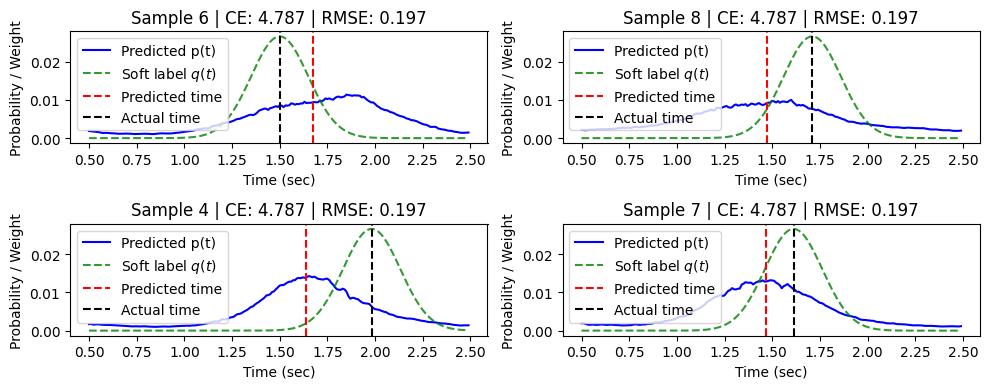

New best validation NRMSE: 962.470369 at epoch 1
Epoch 2/10: 

Epoch 2 [47/47] Loss 6.2943 CE 5.0354 RMSE 0.4196 KL 0.0000 WASS 0.0000 NRMSE 0.9668 Entropy 5.037: 100%|██████████| 47/47 [00:59<00:00,  1.26s/it]

NRMSE: 0.9668 Total loss: 292.2518 Total CE: 236.0658 Total RMSE: 18.7287 Total KL: 0.0000 Total WASS: 0.0000



Val [91/91] Loss 4.9251 CE 4.7293 RMSE 0.1958 NRMSE 0.9536: 100%|██████████| 91/91 [00:04<00:00, 20.88it/s]


Val NRMSE: 953.566, Val Loss: 5.321735, Val CE: 4.944894, Val RMSE: 0.376841
mean bias (s): -0.062309253960847855


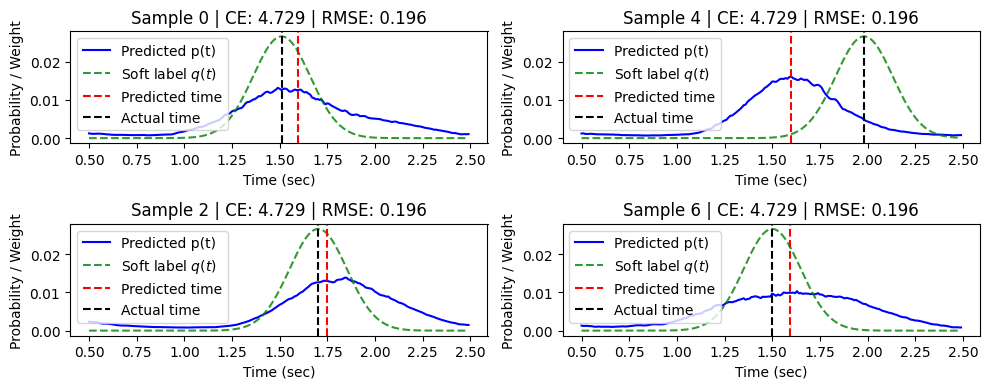

New best validation NRMSE: 953.566138 at epoch 2
Epoch 3/10: 

Epoch 3 [47/47] Loss 6.2350 CE 5.0173 RMSE 0.4059 KL 0.0000 WASS 0.0000 NRMSE 0.9590 Entropy 5.029: 100%|██████████| 47/47 [00:59<00:00,  1.26s/it]

NRMSE: 0.9590 Total loss: 291.0666 Total CE: 235.2827 Total RMSE: 18.5946 Total KL: 0.0000 Total WASS: 0.0000



Val [91/91] Loss 4.8476 CE 4.6718 RMSE 0.1757 NRMSE 0.9458: 100%|██████████| 91/91 [00:04<00:00, 21.11it/s]


Val NRMSE: 945.798, Val Loss: 5.296692, Val CE: 4.924082, Val RMSE: 0.372610
mean bias (s): -0.03671541437506676


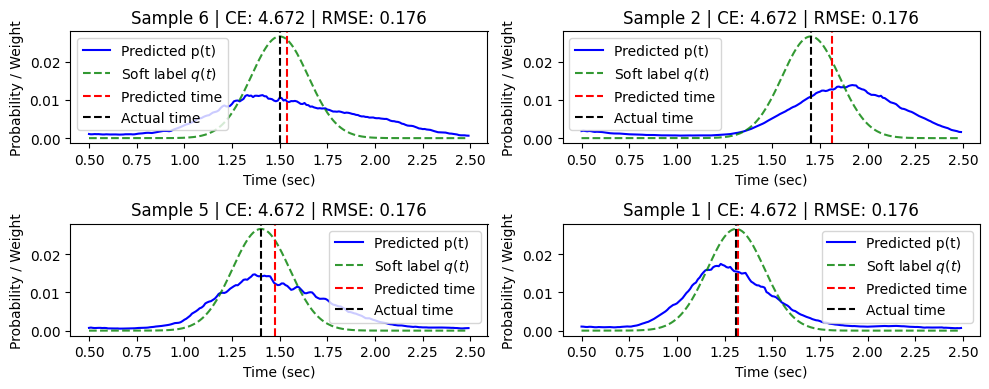

New best validation NRMSE: 945.797517 at epoch 3
Epoch 4/10: 

Epoch 4 [47/47] Loss 6.2270 CE 5.0184 RMSE 0.4029 KL 0.0000 WASS 0.0000 NRMSE 0.9558 Entropy 5.031: 100%|██████████| 47/47 [00:59<00:00,  1.26s/it]

NRMSE: 0.9558 Total loss: 290.4941 Total CE: 234.8967 Total RMSE: 18.5325 Total KL: 0.0000 Total WASS: 0.0000



Val [91/91] Loss 4.9459 CE 4.7601 RMSE 0.1859 NRMSE 0.9451: 100%|██████████| 91/91 [00:04<00:00, 21.05it/s]


Val NRMSE: 945.138, Val Loss: 5.297443, Val CE: 4.925084, Val RMSE: 0.372359
mean bias (s): -0.00735451141372323


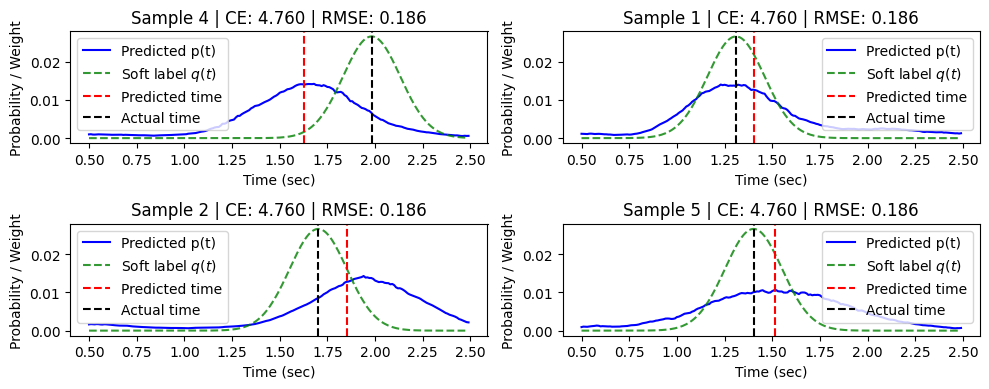

New best validation NRMSE: 945.138243 at epoch 4
Epoch 5/10: 

Epoch 5 [47/47] Loss 6.1428 CE 4.9667 RMSE 0.3920 KL 0.0000 WASS 0.0000 NRMSE 0.9497 Entropy 4.980: 100%|██████████| 47/47 [00:59<00:00,  1.26s/it]

NRMSE: 0.9497 Total loss: 289.4638 Total CE: 234.2745 Total RMSE: 18.3964 Total KL: 0.0000 Total WASS: 0.0000



Val [91/91] Loss 4.9208 CE 4.7283 RMSE 0.1924 NRMSE 0.9460: 100%|██████████| 91/91 [00:04<00:00, 20.87it/s]


Val NRMSE: 946.015, Val Loss: 5.293408, Val CE: 4.920638, Val RMSE: 0.372771
mean bias (s): -0.08577512204647064


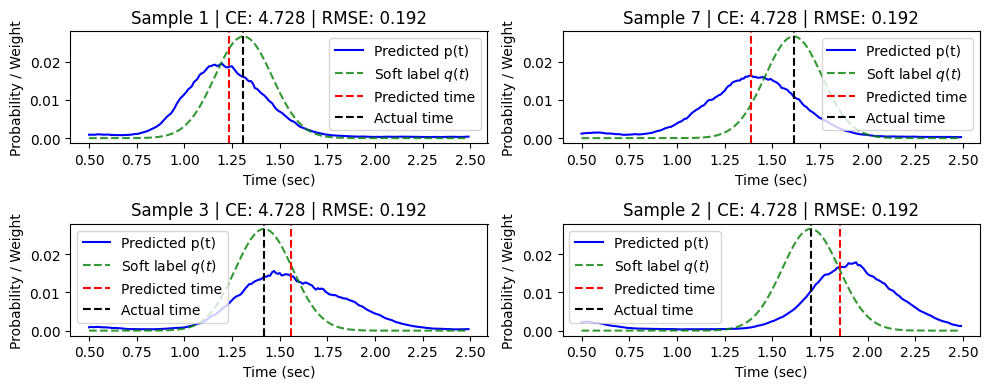

Epoch 6/10: 

Epoch 6 [47/47] Loss 6.1930 CE 5.0090 RMSE 0.3947 KL 0.0000 WASS 0.0000 NRMSE 0.9435 Entropy 4.934: 100%|██████████| 47/47 [00:59<00:00,  1.26s/it]

NRMSE: 0.9435 Total loss: 288.7861 Total CE: 233.9066 Total RMSE: 18.2932 Total KL: 0.0000 Total WASS: 0.0000



Val [91/91] Loss 4.8442 CE 4.6760 RMSE 0.1682 NRMSE 0.9296: 100%|██████████| 91/91 [00:04<00:00, 21.01it/s]


Val NRMSE: 929.551, Val Loss: 5.254616, Val CE: 4.889446, Val RMSE: 0.365170
mean bias (s): -0.02283281832933426


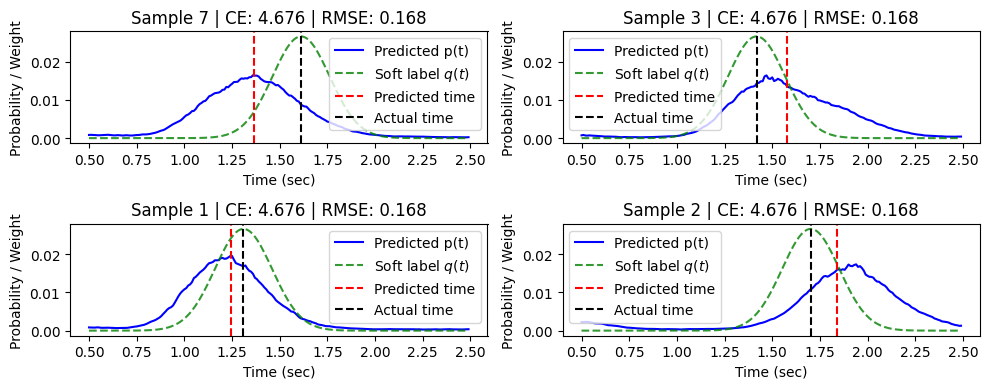

New best validation NRMSE: 929.551145 at epoch 6
Epoch 7/10: 

Epoch 7 [47/47] Loss 6.1242 CE 4.9491 RMSE 0.3917 KL 0.0000 WASS 0.0000 NRMSE 0.9384 Entropy 4.957: 100%|██████████| 47/47 [00:59<00:00,  1.26s/it]

NRMSE: 0.9384 Total loss: 287.9368 Total CE: 233.3369 Total RMSE: 18.2000 Total KL: 0.0000 Total WASS: 0.0000



Val [91/91] Loss 4.8838 CE 4.7111 RMSE 0.1727 NRMSE 0.9276: 100%|██████████| 91/91 [00:04<00:00, 20.71it/s]


Val NRMSE: 927.567, Val Loss: 5.255573, Val CE: 4.890454, Val RMSE: 0.365119
mean bias (s): -0.06619434803724289


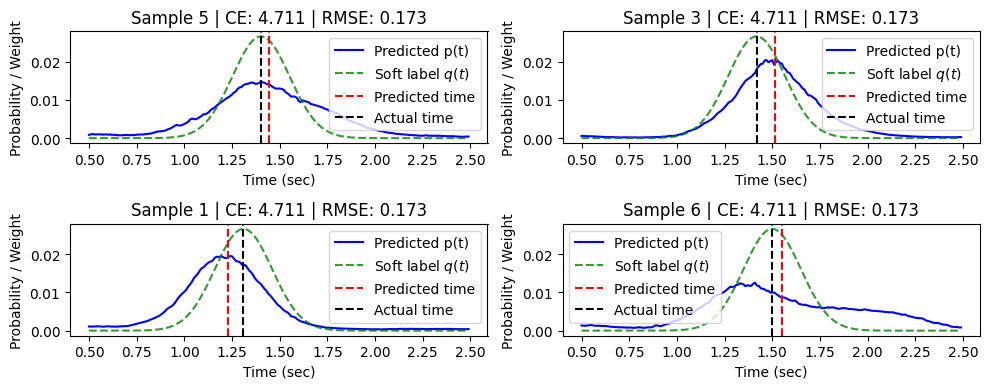

New best validation NRMSE: 927.567110 at epoch 7
Epoch 8/10: 

Epoch 8 [47/47] Loss 6.0959 CE 4.9398 RMSE 0.3854 KL 0.0000 WASS 0.0000 NRMSE 0.9337 Entropy 4.961: 100%|██████████| 47/47 [00:59<00:00,  1.26s/it]

NRMSE: 0.9337 Total loss: 287.1831 Total CE: 232.9410 Total RMSE: 18.0807 Total KL: 0.0000 Total WASS: 0.0000



Val [91/91] Loss 4.8707 CE 4.6847 RMSE 0.1861 NRMSE 0.9262: 100%|██████████| 91/91 [00:04<00:00, 20.88it/s]


Val NRMSE: 926.153, Val Loss: 5.241661, Val CE: 4.878018, Val RMSE: 0.363644
mean bias (s): -0.042795103043317795


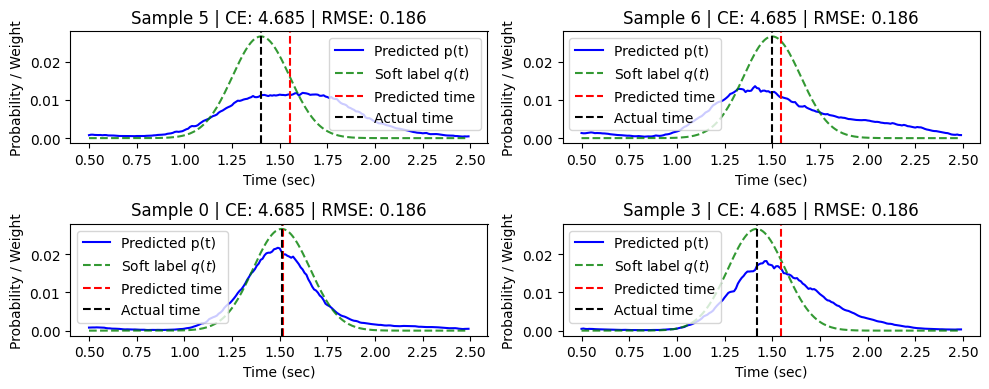

New best validation NRMSE: 926.152984 at epoch 8
Epoch 9/10: 

Epoch 9 [47/47] Loss 6.0977 CE 4.9374 RMSE 0.3868 KL 0.0000 WASS 0.0000 NRMSE 0.9301 Entropy 4.934: 100%|██████████| 47/47 [00:59<00:00,  1.26s/it]

NRMSE: 0.9301 Total loss: 286.8209 Total CE: 232.7107 Total RMSE: 18.0367 Total KL: 0.0000 Total WASS: 0.0000



Val [91/91] Loss 4.9032 CE 4.7242 RMSE 0.1790 NRMSE 0.9242: 100%|██████████| 91/91 [00:04<00:00, 20.65it/s]


Val NRMSE: 924.245, Val Loss: 5.238742, Val CE: 4.875713, Val RMSE: 0.363029
mean bias (s): -0.07772021740674973


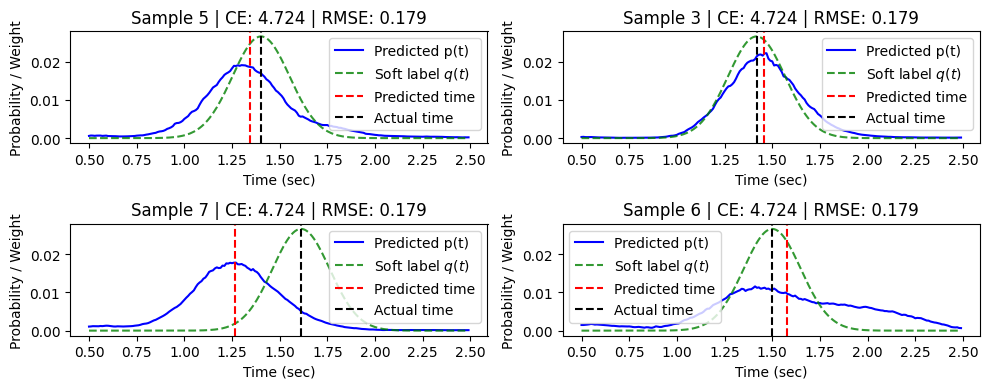

New best validation NRMSE: 924.245319 at epoch 9
Epoch 10/10: 

Epoch 10 [47/47] Loss 6.0686 CE 4.9551 RMSE 0.3712 KL 0.0000 WASS 0.0000 NRMSE 0.9273 Entropy 4.930: 100%|██████████| 47/47 [00:59<00:00,  1.26s/it]

NRMSE: 0.9273 Total loss: 286.2997 Total CE: 232.4818 Total RMSE: 17.9393 Total KL: 0.0000 Total WASS: 0.0000



Val [91/91] Loss 4.8215 CE 4.6546 RMSE 0.1669 NRMSE 0.9237: 100%|██████████| 91/91 [00:04<00:00, 21.01it/s]


Val NRMSE: 923.673, Val Loss: 5.239337, Val CE: 4.876378, Val RMSE: 0.362958
mean bias (s): -0.03718883544206619


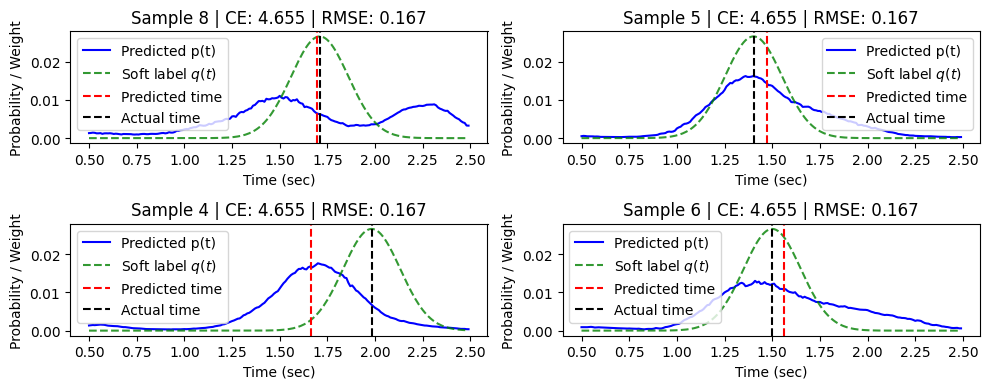

New best validation NRMSE: 923.673345 at epoch 10


In [11]:
import copy

finetune_mode = False
demonstration_mode = True

n_epochs = 10 if demonstration_mode else 100
early_stopping_patience = 5 if demonstration_mode else 10

early_stopping_patience = 20
use_augmentation = True if finetune_mode else True
initial_lr = 1E-4 if finetune_mode else 0.001
weight_decay = 0 if finetune_mode else 0
optimizer_module = torch.optim.SGD if finetune_mode else torch.optim.Adam
batch_size = 2000 if finetune_mode else 2000
sigma = 0.15 if finetune_mode else 0.15 # 0.13
cropping_offset = 0.2 if finetune_mode else 0.25
crop_proba = 0.1 if finetune_mode else 0.3
dropout_proba = 0.3 if finetune_mode else 0.25
dropout_range = 0.2 if finetune_mode else 0.8
mixup_p = 0.5 if finetune_mode else 0.1 #0.8 
temperature = 0.75 if finetune_mode else 0.65 # 0.7
lambda_time = 0 if finetune_mode else 3. # 5
lambda_ce = 1.0 if finetune_mode else 0 # 1
lambda_wass = 0.0 if finetune_mode else 0. # 0.001
lambda_kl = 0. if finetune_mode else 0
lambda_entropy = -0.0 if finetune_mode else 0
lambda_focal = 0.
lambda_hazard = 0.0
grad_accum = 1

train_cropping_dataset = TrainCroppingDataset(
    train_dataset, sfreq=100, crop_sec=2.0, sigma=sigma, use_channels=channels_list, end_time=3,
    use_augmentation=use_augmentation, cropping_offset=cropping_offset, crop_proba=crop_proba,
    dropout_proba=dropout_proba, dropout_range=dropout_proba
)
train_loader = DataLoader(
    train_cropping_dataset, batch_size=batch_size, shuffle=True, num_workers=8, 
    # pin_memory=True, persistent_workers=True, prefetch_factor=4
)
current_lr = initial_lr
optimizer = optimizer_module(model.parameters(), lr=current_lr, weight_decay=weight_decay)

for epoch in range(1, n_epochs + 1):
    print(f"Epoch {epoch}/{n_epochs}: ", end="")

    train_loss, train_nrmse, train_loss_dict = train_one_epoch(
        train_loader, model, optimizer, epoch, device,
        mixup_p=mixup_p, 
        # lambda_time=time_lambda, lambda_kl=0.5, lambda_wass=0.5,
        lambda_time=lambda_time, lambda_kl=lambda_kl, lambda_wass=lambda_wass,
        lambda_entropy = lambda_entropy, lambda_focal=lambda_focal,
        lambda_hazard=lambda_hazard,
        temperature=temperature, grad_accum=grad_accum,
    )

    val_preds, val_loss, val_nrmse, val_ce, val_mse = valid_model(
        valid_loader, model, device, sigma=sigma,
        lambda_time=1., temperature=temperature,
        channels_list=channels_list, default_rmse=default_rmse_valid,
        plot_last_batch=True,
        use_soft_argmax=True
    )

    if val_nrmse < best_rmse:
        print(f"New best validation NRMSE: {val_nrmse:.6f} at epoch {epoch}")
        best_rmse = val_nrmse
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(model.state_dict(), output_checkpoint_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            current_checkpoint_path = output_checkpoint_path if os.path.exists(output_checkpoint_path) else input_checkpoint_path
            print(f"Restart from checkpoint {current_checkpoint_path}. Best Val NRMSE: {best_rmse:.6f} (epoch {best_epoch})")
            print(f"Updating learning rate {current_lr} -> {current_lr * 0.5}")
            model.load_state_dict(torch.load(current_checkpoint_path))
            current_lr = current_lr * 0.5
            optimizer = optimizer_module(model.parameters(), lr=current_lr, weight_decay=weight_decay)
            epochs_no_improve = 0

## After finishing training you can simply switch to finetune_mode and continue the training process until best convergance